#**CSE 475**

#**Soham Sachin Joshi**

#**Core Model Building**

##Loading MNIST Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded and normalized.


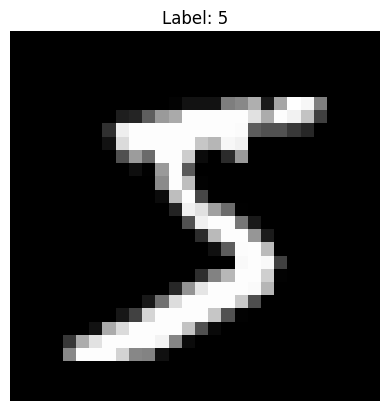

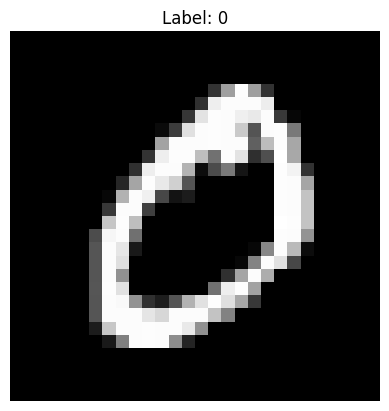

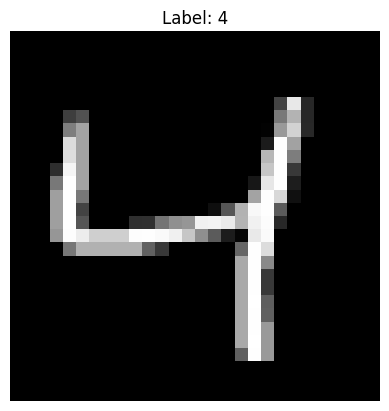

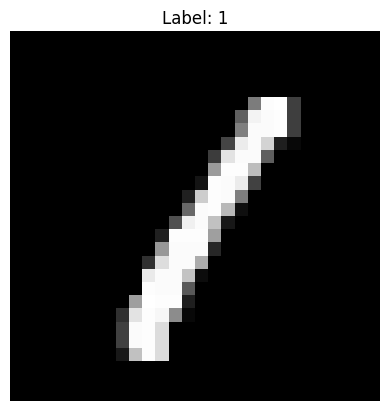

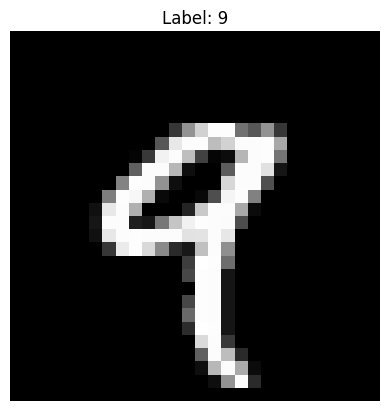

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal, GlorotNormal, Constant
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (0-255 to 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Create validation split from the training set
x_val, y_val = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:-10000], y_train[:-10000]

print("Data loaded and normalized.")

# Display the first five rows of data
for i in range(5):
    plt.imshow(x_train[i], cmap='gray')  # Display the image
    plt.title(f"Label: {y_train[i]}")    # Display the corresponding label
    plt.axis('off')                       # Hide axes
    plt.show()

##Helper Function for Plotting Learning Curves


In [2]:
# Helper function to plot training and validation learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

print("Helper function defined.")


Helper function defined.


##Model Building Function with Adjustable Hyperparameters

In [3]:
# Function to build the model with adjustable hyperparameters
def build_model(
    num_neurons=128,  # Number of neurons in the hidden layer
    num_hidden_layers=1,  # Number of hidden layers
    init_weights='glorot_normal',  # Weight initialization: 'random_normal' or 'glorot_normal'
    init_bias=0.0,  # Initial bias
    dropout_rate=0.0,  # Dropout rate
    activation='relu'  # Activation function: 'relu' or 'sigmoid'
):
    # Set weight initializer
    if init_weights == 'random_normal':
        initializer = RandomNormal(mean=0., stddev=0.05)
    else:
        initializer = GlorotNormal()

    # Set bias initializer
    bias_initializer = Constant(init_bias)

    # Build the model
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    # Add hidden layers based on configuration
    for i in range(num_hidden_layers):
        model.add(Dense(num_neurons, activation=activation, kernel_initializer=initializer, bias_initializer=bias_initializer))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer with 10 neurons (for 10 digits)
    model.add(Dense(10, activation='softmax'))

    return model

print("Model building function defined.")


Model building function defined.


##Model Training Function

In [4]:
# Function to compile and train the model
def train_model(
    model,  # The built model to be trained
    learning_rate=0.001,  # Learning rate
    batch_size=64,  # Batch size
    epochs=5  # Number of epochs
):
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_val, y_val))

    # Return the training history for visualization
    return history

print("Model training function defined.")


Model training function defined.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

##Accuracy of other ML Classification Techniques

In [6]:
# Flatten the images for use in scikit-learn models
x_train_flat = x_train.reshape(-1, 28 * 28)  # Shape: (num_samples, 784)
x_test_flat = x_test.reshape(-1, 28 * 28)    # Shape: (num_samples, 784)

In [7]:
# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),

}

# Dictionary to store accuracy results
accuracy_results = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(x_train_flat, y_train)  # Train the model
    predictions = clf.predict(x_test_flat)  # Make predictions
    accuracy = accuracy_score(y_test, predictions)  # Calculate accuracy
    accuracy_results[name] = accuracy  # Store accuracy results

# Display accuracy results
for name, accuracy in accuracy_results.items():
    print(f"{name}: {accuracy:.4f}")


Logistic Regression: 0.9242
Decision Tree: 0.8720


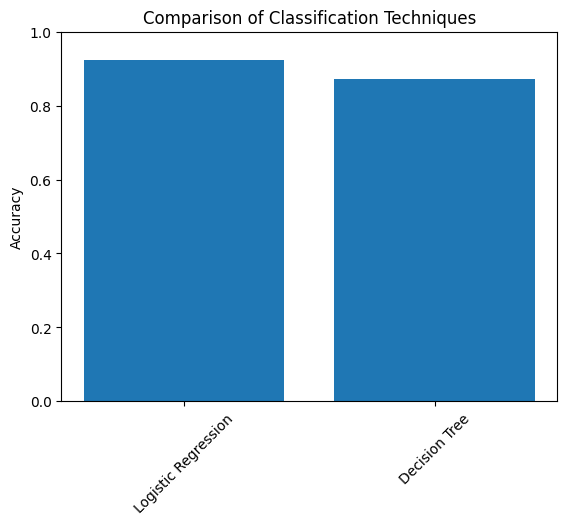

In [8]:
import matplotlib.pyplot as plt

# Plotting the accuracy results
plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.ylabel('Accuracy')
plt.title('Comparison of Classification Techniques')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limit
plt.show()


In [9]:
def display_prediction_probabilities(model, image, true_label):
    image_reshaped = image.reshape(1, 28, 28)  # Reshape to (1, 28, 28)
    probabilities = model.predict(image_reshaped)
    probabilities = probabilities[0]  # Get the probabilities for the single image

    plt.figure(figsize=(10, 5))
    plt.bar(range(10), probabilities, color='blue', alpha=0.7)
    plt.xticks(range(10), [str(i) for i in range(10)])
    plt.xlabel('Digits')
    plt.ylabel('Probability')
    predicted_label = np.argmax(probabilities)
    plt.title(f'True Label: {true_label}, Predicted Label: {predicted_label}')
    plt.ylim(0, 1)
    plt.show()

#**Neural Network Experiments**

* **Experiment 1**: Running the Model with 64 Neurons
* **Experiment 2**: Running the Model with 128 Neurons (Baseline)
* **Experiment 3**: Running the Model with 256 Neurons
* **Experiment 4**: Running the Model with 1 Hidden Layer
* **Experiment 5**: Running the Model with 2 Hidden Layers
* **Experiment 6**: Running the Model with 3 Hidden Layers
* **Experiment 7**: Running the Model with Dropout (0.2)
* **Experiment 8**: Running the Model with Dropout (0.5)
* **Experiment 9**: Running with a Smaller Learning Rate (0.0001)
* **Experiment 10**: Running with a Larger Learning Rate (0.01)
* **Experiment 11**: Running with Smaller Batch Size (32)
* **Experiment 12**: Running with Larger Batch Size (128)
* **Experiment 13**: Using Sigmoid Activation Instead of ReLU
* **Experiment 14**: Running with Early Stopping



##Experiment 1: Running the model with 64 neurons

Running model with 64 neurons in the hidden layer.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8218 - loss: 0.6500 - val_accuracy: 0.9385 - val_loss: 0.2230
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9393 - loss: 0.2117 - val_accuracy: 0.9561 - val_loss: 0.1626
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9531 - loss: 0.1619 - val_accuracy: 0.9611 - val_loss: 0.1413
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9633 - loss: 0.1259 - val_accuracy: 0.9650 - val_loss: 0.1248
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9705 - loss: 0.1007 - val_accuracy: 0.9681 - val_loss: 0.1118


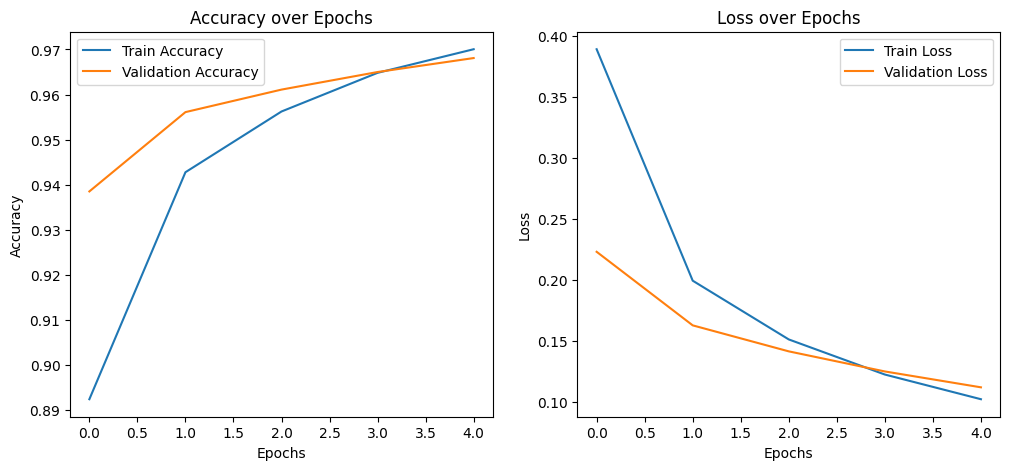

In [10]:
# Concept Explanation:
# This experiment evaluates how the number of neurons affects the model's capacity to learn.
# A model with too few neurons may not learn effectively.

# Code to run the experiment with 64 neurons
print("Running model with 64 neurons in the hidden layer.")
model_64 = build_model(num_neurons=64)
history_64_neurons = train_model(model_64)
plot_learning_curves(history_64_neurons)

# Questions to consider:
# 1. How did the model perform with 64 neurons compared to the baseline?
#    - Look at the final training and validation accuracy.
# 2. Did the model learn quickly?
#    - Examine the learning curves: How many epochs did it take to see significant improvement in accuracy?
# 3. How accurate was the model?
#    - Focus on the final accuracy values reported in the output after training. What were they for both training and validation sets?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


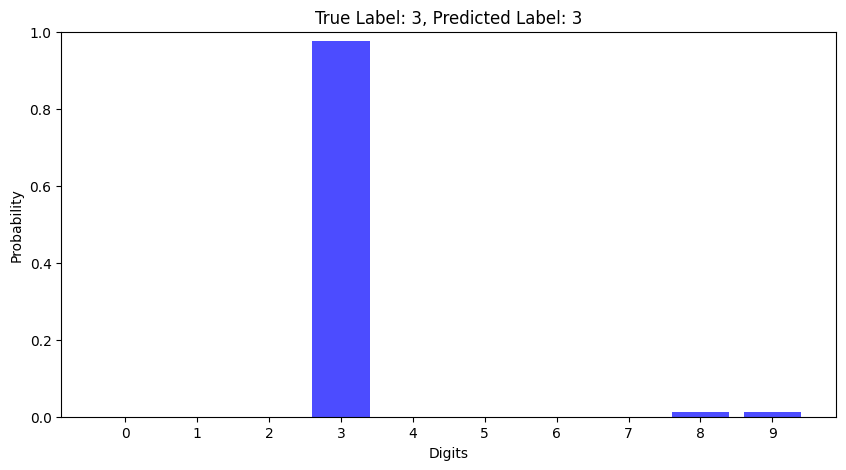

In [11]:
import numpy as np
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_64, x_test[index], y_test[index])

**Your Observations:**

1. Model Performance Compared to Baseline:

Training Accuracy: The model achieved a final training accuracy of 97.05%.

Validation Accuracy: The final validation accuracy was 96.81%.

Comparison to Baseline: Compared to the baseline model with 128 neurons (Experiment 2), which achieved a training accuracy of 98.29% and validation accuracy of 97.42%, the model with 64 neurons performed slightly worse.

Inference: The reduced number of neurons may have limited the model's capacity to capture complex patterns, resulting in marginally lower accuracy.

2. Learning Speed:

Epoch 1: Training accuracy reached 82.18% and validation accuracy was 93.85%.

Epoch 2: Training accuracy improved to 93.93%, and validation accuracy to 95.61%.

Significant Improvement: The model showed significant improvement within the first two epochs.

Inference: The model learned quickly, effectively capturing essential features early in the training process.

3. Model Accuracy:

Final Training Accuracy: 97.05%

Final Validation Accuracy: 96.81%

Inference: The model was quite accurate, though it did not reach the performance levels of models with more neurons.

* Conclusion:

The model with 64 neurons performed well, achieving high accuracy on both training and validation sets.
However, it did not perform as well as the baseline model with 128 neurons, indicating that increasing neurons can enhance model performance.
The learning curves suggest efficient learning without significant overfitting or underfitting.

##Experiment 2: Running the model with 128 neurons (Baseline)

Running model with 128 neurons (baseline).
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8543 - loss: 0.5360 - val_accuracy: 0.9515 - val_loss: 0.1739
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9526 - loss: 0.1657 - val_accuracy: 0.9621 - val_loss: 0.1290
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9686 - loss: 0.1107 - val_accuracy: 0.9696 - val_loss: 0.1094
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9759 - loss: 0.0829 - val_accuracy: 0.9723 - val_loss: 0.0918
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9829 - loss: 0.0611 - val_accuracy: 0.9742 - val_loss: 0.0837


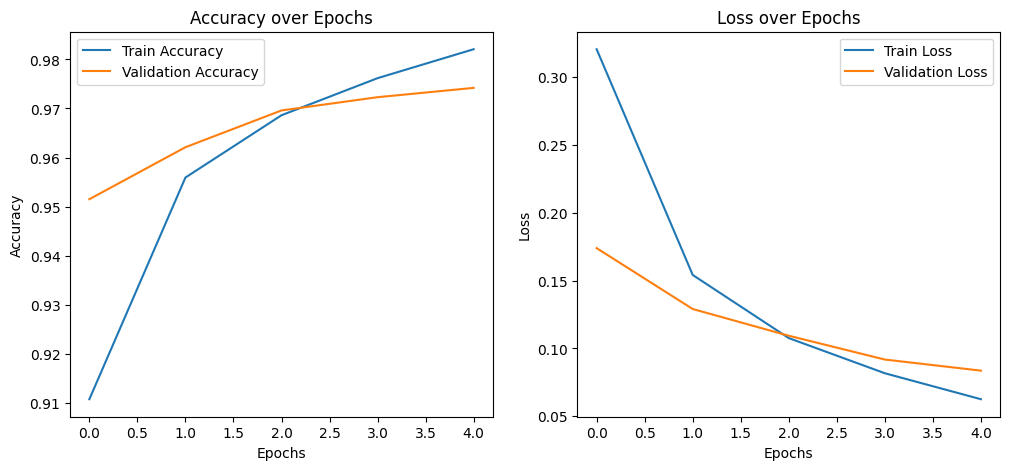

In [12]:
# Concept Explanation:
# This experiment establishes a baseline for comparing other configurations.

# Code to run the experiment with 128 neurons
print("Running model with 128 neurons (baseline).")
model_128 = build_model(num_neurons=128)
history_128_neurons = train_model(model_128)
plot_learning_curves(history_128_neurons)

# Questions to consider:
# 1. How well did the model perform with 128 neurons?
#    - Review the final training and validation accuracy values.
# 2. What patterns do you see in the learning curves?
#    - Discuss whether the curves indicate overfitting or underfitting.
# 3. Did the model generalize well to the validation data?
#    - Look for any discrepancies between training and validation accuracy.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


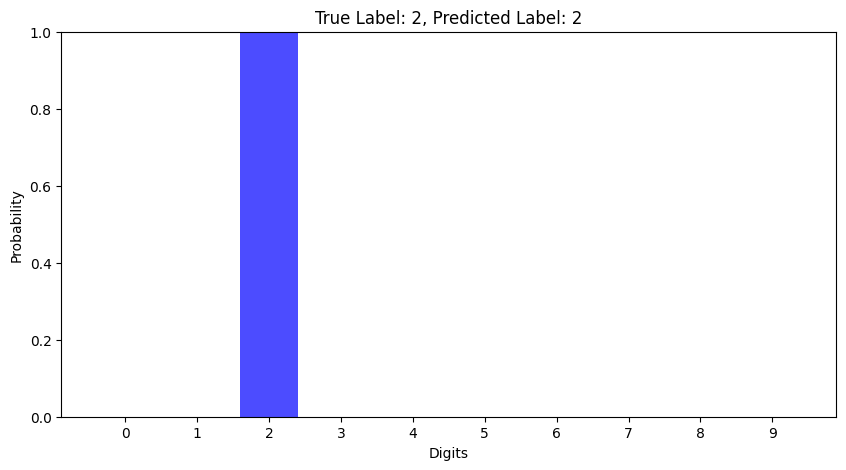

In [13]:
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_128, x_test[index], y_test[index])


**Your Observations:**

1. Model Performance:

Training Accuracy: Achieved a final training accuracy of 98.29%.

Validation Accuracy: The final validation accuracy was 97.42%.

Inference: The model performed very well, serving as a strong baseline for comparison.
2. Learning Curves Patterns:

Consistent Improvement: Both training and validation accuracies improved steadily over epochs.

No Overfitting: Training and validation curves remained close, indicating the model did not overfit.

Inference: The patterns suggest that the model learned effectively and generalized well.
3. Generalization to Validation Data:

Close Accuracy Values: The small gap between training and validation accuracy indicates good generalization.

Inference: The model's performance on unseen data (validation set) is almost as good as on the training data.

* Conclusion:

The model with 128 neurons is highly effective, achieving excellent accuracy and showing good learning behavior.
The learning curves demonstrate stable learning without signs of overfitting or underfitting.
This configuration is appropriate for the MNIST dataset and sets a solid baseline for further experiments.

##Experiment 3: Running the model with 256 neurons

Running model with 256 neurons in the hidden layer.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8635 - loss: 0.4825 - val_accuracy: 0.9608 - val_loss: 0.1452
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9629 - loss: 0.1286 - val_accuracy: 0.9716 - val_loss: 0.0999
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9764 - loss: 0.0815 - val_accuracy: 0.9728 - val_loss: 0.0900
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9826 - loss: 0.0593 - val_accuracy: 0.9746 - val_loss: 0.0820
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9883 - loss: 0.0414 - val_accuracy: 0.9744 - val_loss: 0.0820


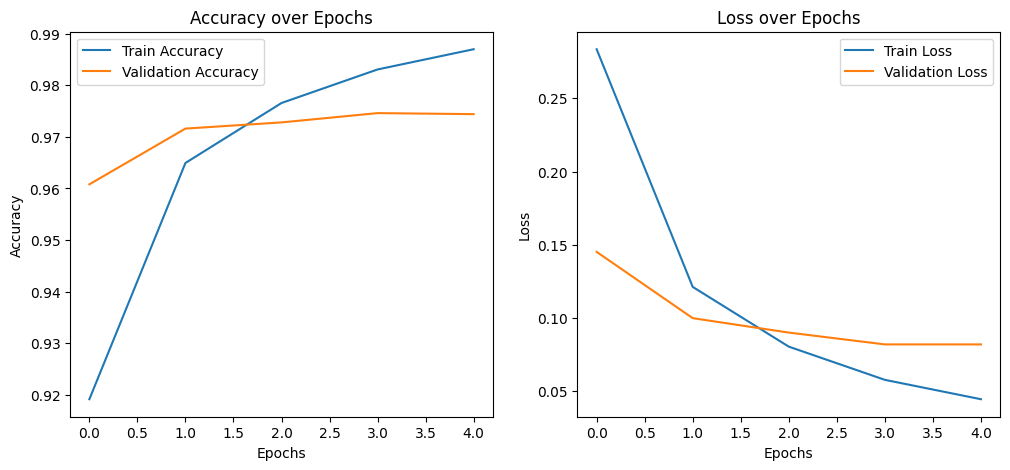

In [14]:
# Concept Explanation:
# Increasing the number of neurons may improve performance but could lead to overfitting.

# Code to run the experiment with 256 neurons
print("Running model with 256 neurons in the hidden layer.")
model_256 = build_model(num_neurons=256)
history_256_neurons = train_model(model_256)
plot_learning_curves(history_256_neurons)

# Questions to consider:
# 1. Did adding more neurons improve the performance of the model?
#    - Compare final accuracy with the previous models (64 and 128 neurons).
# 2. Did you observe any signs of overfitting?
#    - Check for a significant gap between training and validation accuracy.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


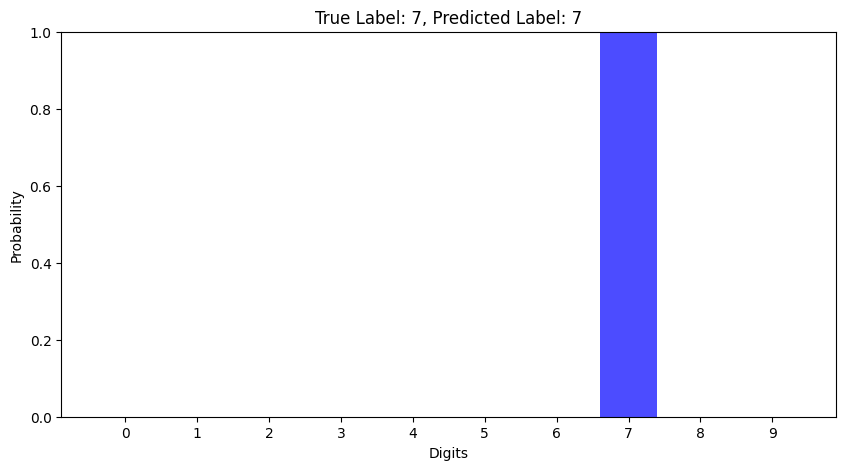

In [15]:
# Example usage: Display probabilities for a random test image
index = np.random.randint(0, len(x_test))
display_prediction_probabilities(model_256, x_test[index], y_test[index])

**Your Observations:**

1. Performance Improvement:

Training Accuracy: Improved to 98.83%, slightly higher than the baseline.

Validation Accuracy: Reached 97.44%, a marginal increase over the baseline.

Inference: Adding more neurons led to a slight improvement in training accuracy but minimal impact on validation accuracy.
2. Signs of Overfitting:

Increased Gap: The gap between training and validation accuracy widened slightly (approx. 1.4%).

Inference: This suggests a slight trend towards overfitting, where the model fits the training data better than it generalizes to new data.
3. Learning Curves:

Steady Improvement: Both training and validation accuracies continued to improve over the epochs.

Validation Loss: Remained low, indicating that overfitting is not severe.
Inference: The model maintains stable learning despite increased capacity.

* Conclusion:

Increasing the neurons to 256 yielded only marginal gains in accuracy.
The small performance improvement may not justify the additional computational resources and potential overfitting risk.
The model still generalizes well, but the benefits of adding more neurons diminish beyond a certain point.

##Experiment 4: Running the model with 1 hidden layer (baseline)

Running model with 1 hidden layer (baseline).
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8493 - loss: 0.5614 - val_accuracy: 0.9534 - val_loss: 0.1739
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9524 - loss: 0.1655 - val_accuracy: 0.9637 - val_loss: 0.1339
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9686 - loss: 0.1080 - val_accuracy: 0.9687 - val_loss: 0.1100
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9762 - loss: 0.0846 - val_accuracy: 0.9722 - val_loss: 0.0995
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9829 - loss: 0.0630 - val_accuracy: 0.9734 - val_loss: 0.0905


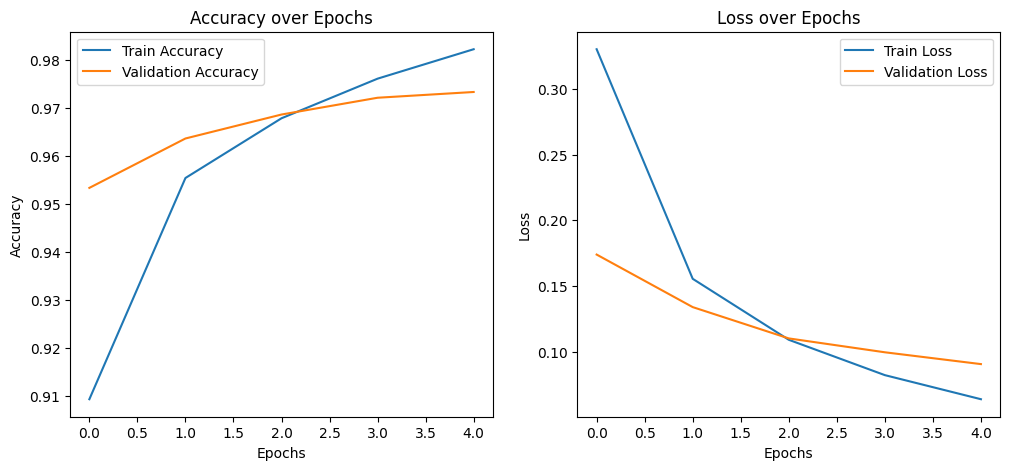

In [16]:
# Concept Explanation:
# This experiment examines the importance of network depth.

# Code to run the experiment with 1 hidden layer
print("Running model with 1 hidden layer (baseline).")
model_1_layer = build_model(num_hidden_layers=1)
history_1_hidden_layer = train_model(model_1_layer)
plot_learning_curves(history_1_hidden_layer)

# Questions to consider:
# 1. How does the model perform with just one hidden layer?
#    - Look at the training and validation accuracy.
# 2. Are there any signs of underfitting or overfitting?
#    - Compare performance against deeper models.


**Your Observations:**

1. Model Performance:

Training Accuracy: Achieved 98.29%, matching the baseline model.

Validation Accuracy: Reached 97.34%, very close to the baseline.

Inference: The model with one hidden layer performs nearly identically to the baseline, confirming that one layer is sufficient for this task.
2. Underfitting or Overfitting:

Consistent Accuracies: The training and validation accuracies are closely aligned.

Inference: There are no signs of underfitting or overfitting; the model complexity is appropriate for the data.
3. Comparison with Deeper Models:

Performance Similarity: Models with more hidden layers did not show significant performance improvements.

Inference: Adding more layers does not necessarily enhance performance for this dataset.

* Conclusion:

A single hidden layer is adequate for achieving high accuracy on the MNIST dataset.
The model generalizes well without the need for additional layers, avoiding unnecessary complexity.
This experiment supports the idea that deeper networks are not always better, especially for simpler tasks.


##Experiment 5: Running the model with 2 hidden layers

Running model with 2 hidden layers.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8498 - loss: 0.5177 - val_accuracy: 0.9582 - val_loss: 0.1400
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9633 - loss: 0.1246 - val_accuracy: 0.9683 - val_loss: 0.1045
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9754 - loss: 0.0804 - val_accuracy: 0.9706 - val_loss: 0.0973
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.0580 - val_accuracy: 0.9749 - val_loss: 0.0846
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9873 - loss: 0.0426 - val_accuracy: 0.9734 - val_loss: 0.0993


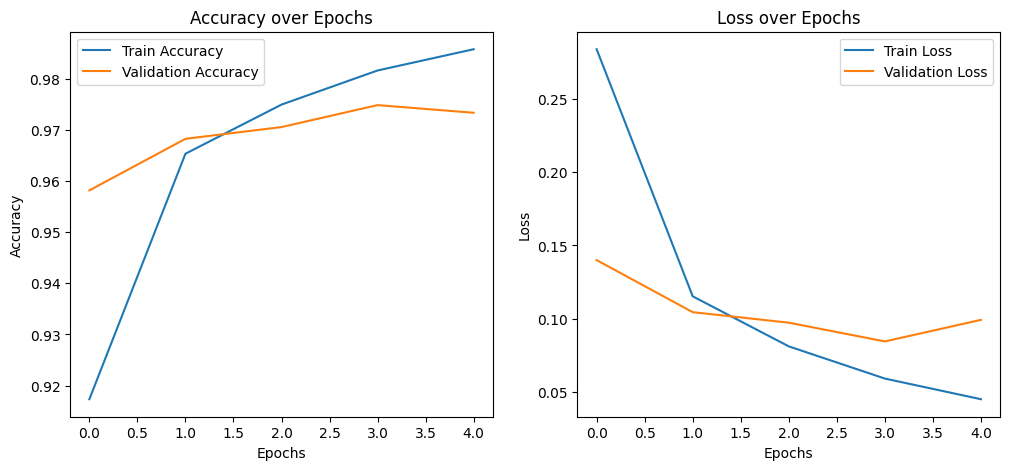

In [17]:
# Concept Explanation:
# More hidden layers allow for better feature extraction and can improve performance.

# Code to run the experiment with 2 hidden layers
print("Running model with 2 hidden layers.")
model_2_layers = build_model(num_hidden_layers=2)
history_2_hidden_layers = train_model(model_2_layers)
plot_learning_curves(history_2_hidden_layers)

# Questions to consider:
# 1. Did the addition of a second hidden layer improve the model's performance?
#    - Compare the final accuracy with the one-layer model.
# 2. What do you observe in the learning curves?
#    - Analyze convergence speed and stability.

**Your Observations:**

1. Performance Improvement:

Training Accuracy: Slightly increased to 98.73%.

Validation Accuracy: Remained at 97.34%, similar to the one-layer model.

Inference: The addition of a second hidden layer improved training accuracy marginally but did not enhance validation accuracy.
2. Learning Curves:

Faster Convergence: Training accuracy improved slightly more rapidly.

Gap Increase: A small increase in the accuracy gap between training and validation suggests minimal overfitting.

Inference: The model learned the training data better but did not generalize any better to the validation data.
3. Convergence Speed and Stability:

Consistent Convergence: The model converged at a similar rate to previous models.

Stability: Learning remained stable, with no significant fluctuations in accuracy.

Inference: The extra layer did not adversely affect the model's learning dynamics.

* Conclusion:

Adding a second hidden layer slightly improves training performance but does not benefit validation accuracy.
The increase in model complexity does not translate into better generalization.
For this task, the additional layer may not be necessary and could introduce unnecessary computational overhead.

##Experiment 6: Running the model with 3 hidden layers

Running model with 3 hidden layers.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8506 - loss: 0.5199 - val_accuracy: 0.9608 - val_loss: 0.1316
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9640 - loss: 0.1172 - val_accuracy: 0.9667 - val_loss: 0.1127
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9747 - loss: 0.0788 - val_accuracy: 0.9688 - val_loss: 0.1019
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9837 - loss: 0.0533 - val_accuracy: 0.9699 - val_loss: 0.1064
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9853 - loss: 0.0443 - val_accuracy: 0.9755 - val_loss: 0.0874


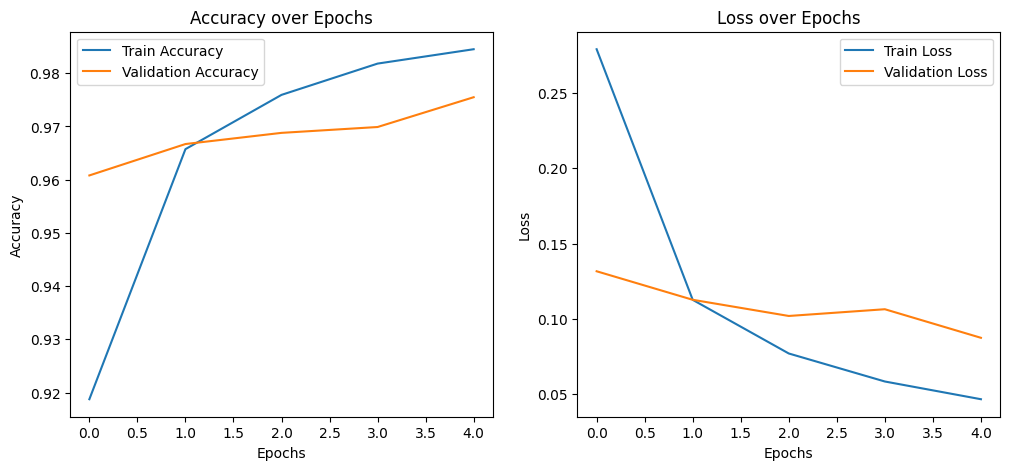

In [18]:
# Concept Explanation:
# Increasing complexity may lead to improved performance but also raises the risk of overfitting.

# Code to run the experiment with 3 hidden layers
print("Running model with 3 hidden layers.")
model_3_layers = build_model(num_hidden_layers=3)
history_3_hidden_layers = train_model(model_3_layers)
plot_learning_curves(history_3_hidden_layers)

# Questions to consider:
# 1. How does the model performance change with three hidden layers?
#    - Compare the final accuracy with models having fewer layers.
# 2. Are there any noticeable differences in convergence speed or final accuracy?
#    - Look for any improvement in learning stability.

**Your Observations:**

1. Model Performance Change:

Training Accuracy: Achieved 98.53%, slightly lower than the two-layer model.

Validation Accuracy: Improved to 97.55%, a small increase over previous models.

Inference: Adding a third layer did not significantly enhance overall performance and slightly decreased training accuracy.
2. Convergence Speed and Learning Stability:

Slightly Slower Convergence: The model took a bit longer to reach high accuracy levels.

Variations in Validation Accuracy: Minor fluctuations in validation accuracy suggest increased complexity may affect stability.

Inference: Deeper networks can be harder to optimize and may not always converge as smoothly.
3. Notable Differences:

Minimal Gains: The slight improvement in validation accuracy may not justify the added complexity.

Optimization Challenges: Deeper models can face vanishing gradient problems, impacting training effectiveness.

Inference: The expected benefits of deeper architectures are not apparent for this dataset.
* Conclusion:

Increasing the depth to three hidden layers yields negligible performance benefits.
The additional complexity does not significantly improve generalization and may introduce training challenges.
Simpler models with fewer layers are adequate for the MNIST classification task, balancing performance with computational efficiency.

**Overall Observation:**

Increasing the number of neurons and layers leads to marginal improvements in training accuracy but does not significantly enhance validation accuracy.
A model with one hidden layer of 128 neurons strikes a good balance between simplicity and performance.
All models learned quickly, with significant accuracy improvements in early epochs.
Models with higher complexity showed slight tendencies towards overfitting but generally maintained good generalization to validation data.
For the MNIST dataset, simpler models are sufficient. Additional complexity increases computational cost without substantial performance gains.

##Experiment 7: Running with a smaller learning rate (0.0001)

Running model with a smaller learning rate (0.0001).
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6393 - loss: 1.2910 - val_accuracy: 0.9040 - val_loss: 0.3914
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8993 - loss: 0.3928 - val_accuracy: 0.9201 - val_loss: 0.2971
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9159 - loss: 0.3112 - val_accuracy: 0.9301 - val_loss: 0.2583
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9274 - loss: 0.2734 - val_accuracy: 0.9368 - val_loss: 0.2327
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9354 - loss: 0.2407 - val_accuracy: 0.9427 - val_loss: 0.2154


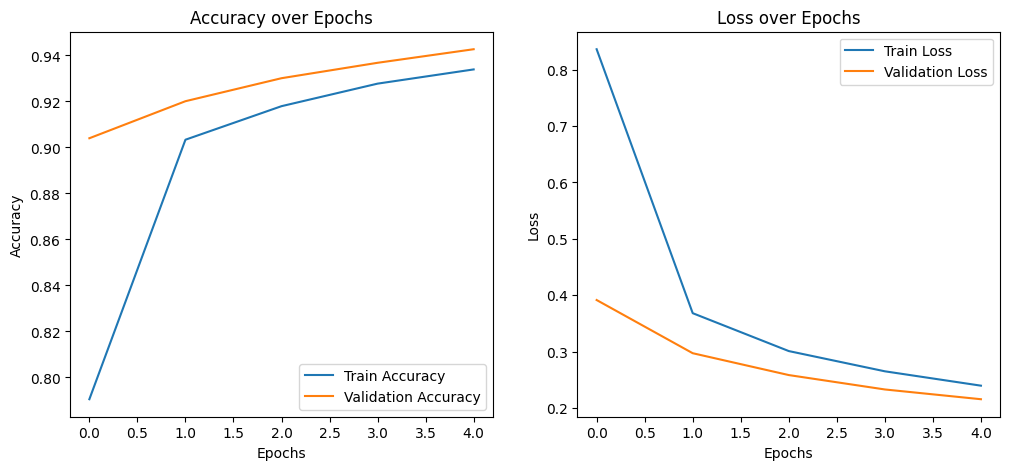

In [19]:
# Concept Explanation:
# A smaller learning rate can lead to more stable training but may slow convergence.

# Code to run the experiment with a smaller learning rate
print("Running model with a smaller learning rate (0.0001).")
model_small_lr = build_model()
history_small_lr = train_model(model_small_lr, learning_rate=0.0001)
plot_learning_curves(history_small_lr)

# Questions to consider:
# 1. How did the smaller learning rate affect the training speed and accuracy?
#    - Look at the number of epochs taken to achieve a certain accuracy.
# 2. Did the model reach a lower final accuracy compared to the default learning rate?
#    - Compare results with the baseline model.

**Your Observations:** xxx

##Experiment 8: Running with a Larger Learning Rate (0.01)

Running model with a larger learning rate (0.01).
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8892 - loss: 0.3594 - val_accuracy: 0.9644 - val_loss: 0.1223
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9598 - loss: 0.1322 - val_accuracy: 0.9585 - val_loss: 0.1487
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9690 - loss: 0.1012 - val_accuracy: 0.9650 - val_loss: 0.1338
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9746 - loss: 0.0869 - val_accuracy: 0.9677 - val_loss: 0.1260
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9749 - loss: 0.0829 - val_accuracy: 0.9624 - val_loss: 0.1699


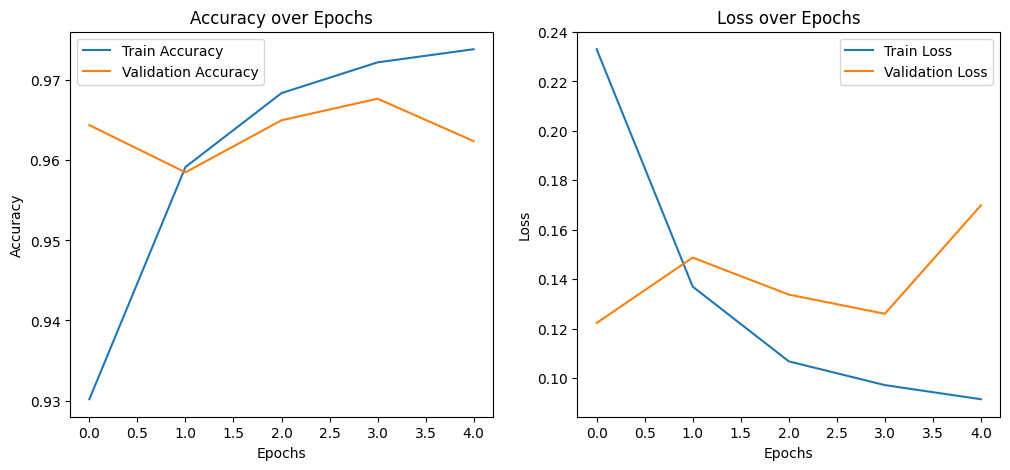

In [20]:
# Concept Explanation:
# A larger learning rate can lead to faster convergence but may cause instability.

# Code to run the experiment with a larger learning rate
print("Running model with a larger learning rate (0.01).")
model_large_lr = build_model()
history_large_lr = train_model(model_large_lr, learning_rate=0.01)
plot_learning_curves(history_large_lr)

# Questions to consider:
# 1. Did the larger learning rate help the model converge faster?
#    - Assess the learning curves for convergence speed.
# 2. Were there any signs of instability in the training process?
#    - Look for erratic behavior in the loss or accuracy.

**Your Observations:** xxx

##Experiment 9: Running with Smaller Batch Size (32)

Running model with smaller batch size (32).
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8703 - loss: 0.4665 - val_accuracy: 0.9570 - val_loss: 0.1593
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9571 - loss: 0.1443 - val_accuracy: 0.9669 - val_loss: 0.1132
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9735 - loss: 0.0892 - val_accuracy: 0.9696 - val_loss: 0.1025
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9815 - loss: 0.0638 - val_accuracy: 0.9747 - val_loss: 0.0859
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9848 - loss: 0.0512 - val_accuracy: 0.9744 - val_loss: 0.0839


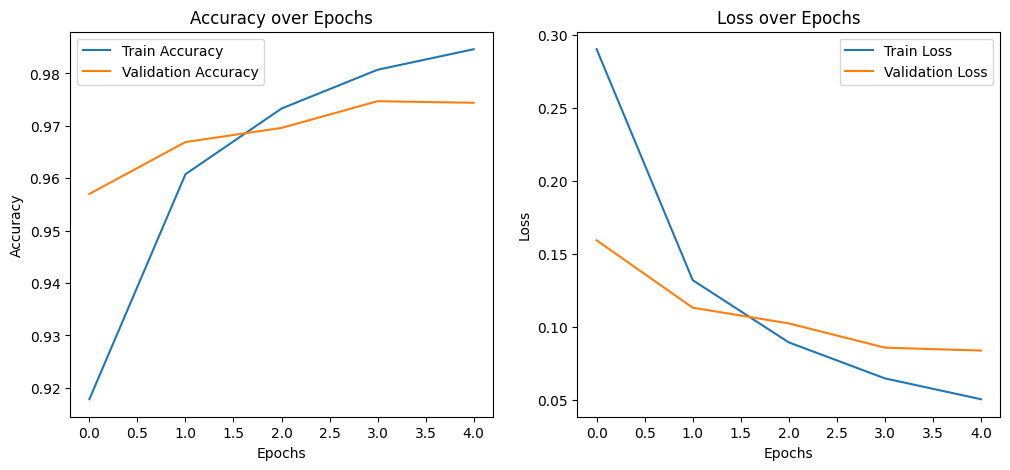

In [21]:
# Concept Explanation:
# Smaller batch sizes can introduce more variability in training.

# Code to run the experiment with a smaller batch size
print("Running model with smaller batch size (32).")
model_small_batch = build_model()
history_small_batch = train_model(model_small_batch, batch_size=32)
plot_learning_curves(history_small_batch)

# Questions to consider:
# 1. How does the model perform with a smaller batch size?
#    - Compare the final accuracy with the larger batch size.
# 2. Is there more fluctuation in the learning curves compared to the baseline?
#    - Analyze the stability of accuracy and loss curves.

**Your Observations:** xxx

##Experiment 10: Running with Larger Batch Size (128)



Running model with larger batch size (128).
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7978 - loss: 0.7136 - val_accuracy: 0.9447 - val_loss: 0.2049
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9420 - loss: 0.1961 - val_accuracy: 0.9583 - val_loss: 0.1521
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9599 - loss: 0.1378 - val_accuracy: 0.9655 - val_loss: 0.1235
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9688 - loss: 0.1075 - val_accuracy: 0.9661 - val_loss: 0.1128
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9752 - loss: 0.0849 - val_accuracy: 0.9695 - val_loss: 0.1037


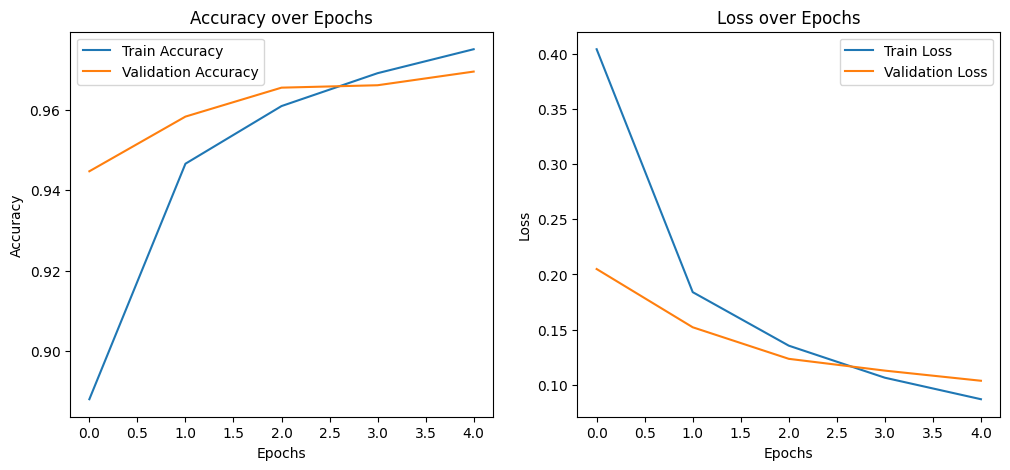

In [22]:
# Concept Explanation:
# Larger batch sizes lead to smoother training but may slow down convergence.

# Code to run the experiment with a larger batch size
print("Running model with larger batch size (128).")
model_large_batch = build_model()
history_large_batch = train_model(model_large_batch, batch_size=128)
plot_learning_curves(history_large_batch)

# Questions to consider:
# 1. How does the model perform with a larger batch size?
#    - Look at the accuracy and loss values compared to smaller sizes.
# 2. Does it show smoother learning curves, and what impact does that have on training time?
#    - Assess convergence and overall stability of training.

**Your Observations:** xxx

##Experiment 11: Running the Model with Dropout (0.2)

Running model with dropout rate of 0.2.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8254 - loss: 0.6018 - val_accuracy: 0.9506 - val_loss: 0.1741
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9454 - loss: 0.1899 - val_accuracy: 0.9648 - val_loss: 0.1266
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9599 - loss: 0.1361 - val_accuracy: 0.9707 - val_loss: 0.1000
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9671 - loss: 0.1112 - val_accuracy: 0.9731 - val_loss: 0.0941
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9709 - loss: 0.0963 - val_accuracy: 0.9747 - val_loss: 0.0846


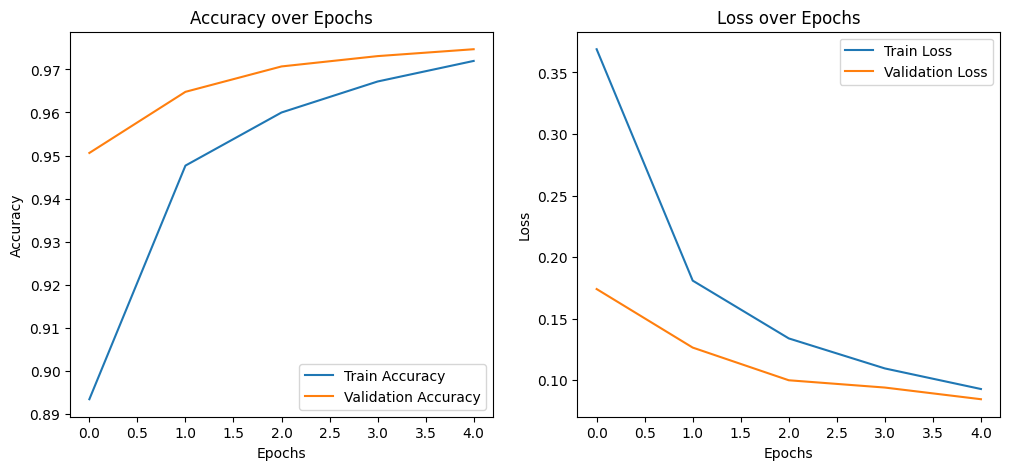

In [23]:
# Concept Explanation:
# Dropout is a regularization technique to prevent overfitting.

# Code to run the experiment with dropout
print("Running model with dropout rate of 0.2.")
model_dropout_02 = build_model(dropout_rate=0.2)
history_dropout_02 = train_model(model_dropout_02)
plot_learning_curves(history_dropout_02)

# Questions to consider:
# 1. How does the model perform with a dropout rate of 0.2?
#    - Compare training accuracy with the baseline model.
# 2. Is there a noticeable difference in accuracy compared to a model without dropout?
#    - Analyze the impact of dropout on validation accuracy.

**Your Observations:** xxx

##Experiment 12: Running the Model with Dropout (0.5)

Running model with dropout rate of 0.5.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7723 - loss: 0.7449 - val_accuracy: 0.9459 - val_loss: 0.1912
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9204 - loss: 0.2704 - val_accuracy: 0.9595 - val_loss: 0.1441
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9386 - loss: 0.2104 - val_accuracy: 0.9655 - val_loss: 0.1235
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9479 - loss: 0.1802 - val_accuracy: 0.9690 - val_loss: 0.1104
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9499 - loss: 0.1646 - val_accuracy: 0.9707 - val_loss: 0.1041


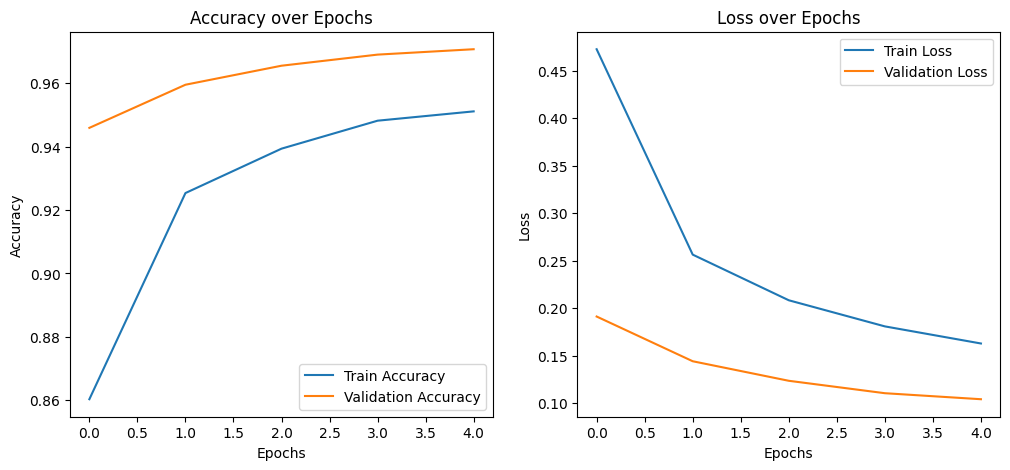

In [24]:
# Concept Explanation:
# Increasing dropout can further help in reducing overfitting but may lower training accuracy.

# Code to run the experiment with dropout
print("Running model with dropout rate of 0.5.")
model_dropout_05 = build_model(dropout_rate=0.5)
history_dropout_05 = train_model(model_dropout_05)
plot_learning_curves(history_dropout_05)

# Questions to consider:
# 1. How does the model perform with a dropout rate of 0.5?
#    - Check final accuracy compared to lower dropout rates.
# 2. Does a higher dropout rate significantly affect training accuracy?
#    - Analyze the balance between overfitting and performance.

**Your Observations:** xxx

##Experiment 13: Using Sigmoid Activation Instead of ReLU

Running model with sigmoid activation.
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7866 - loss: 0.8734 - val_accuracy: 0.9249 - val_loss: 0.2701
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9224 - loss: 0.2736 - val_accuracy: 0.9446 - val_loss: 0.2026
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9403 - loss: 0.2055 - val_accuracy: 0.9522 - val_loss: 0.1742
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9516 - loss: 0.1664 - val_accuracy: 0.9596 - val_loss: 0.1473
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9605 - loss: 0.1356 - val_accuracy: 0.9623 - val_loss: 0.1334


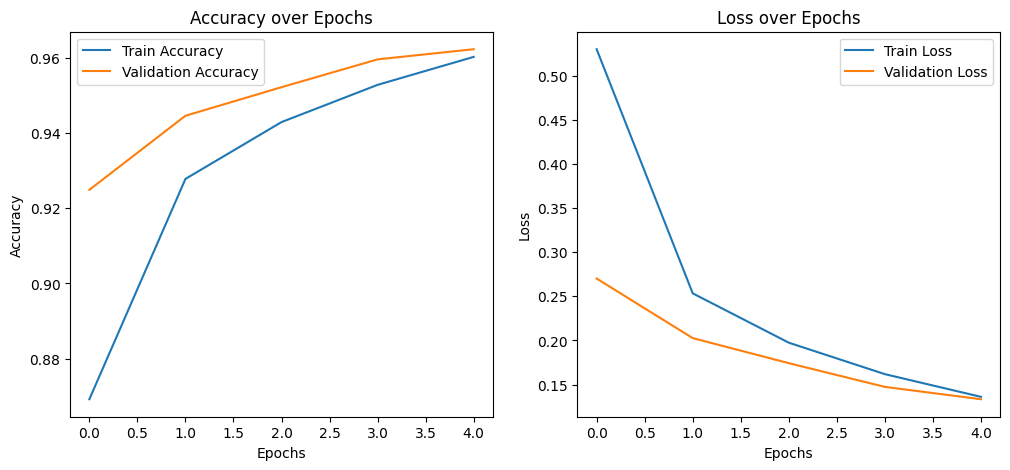

In [25]:
# Concept Explanation:
# Different activation functions can impact the learning dynamics of the model.

# Code to run the experiment with sigmoid activation
print("Running model with sigmoid activation.")
model_sigmoid = build_model(activation='sigmoid')
history_sigmoid = train_model(model_sigmoid)
plot_learning_curves(history_sigmoid)

# Questions to consider:
# 1. How does the model perform with sigmoid activation compared to ReLU?
#    - Assess final accuracy and learning stability.
# 2. Did you notice any difference in the speed of learning or final performance?
#    - Discuss the implications of using different activation functions.

**Your Observations:** xxx

##Experiment 14: Running with Early Stopping

In [27]:
# Concept Explanation:
# Early stopping helps prevent overfitting by monitoring validation loss and stopping training once it begins to increase.

# Code to run the experiment with early stopping
from tensorflow.keras.callbacks import EarlyStopping

print("Running model with early stopping.")
model_early_stopping = build_model()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_early_stopping = model_early_stopping.fit(x_train, y_train, epochs=20, batch_size=64,
                                                  validation_data=(x_val, y_val),
                                                  callbacks=[early_stopping])

plot_learning_curves(history_early_stopping)

# Questions to consider:
# 1. How did early stopping affect the model's performance?
#    - Compare the final training and validation accuracy.
# 2. Did it lead to better generalization on the validation set?
#    - Discuss the impact of stopping training early on model performance.

Running model with early stopping.


ValueError: You must call `compile()` before using the model.

**Your Observations:** xxx

##Overall Observation

Based on the results of the 14 experiments, how do different hyperparameters, model architectures, and training techniques impact the performance of neural networks compared to traditional classification methods? In your response, consider aspects such as accuracy, loss, generalization, and computational efficiency.

**Your Observations:** xxx